In [1]:
import altair as alt
# import cohere
import copy
import csv
import json
import matplotlib.pyplot as plt
import numpy as np
import os
# import openai
import pandas as pd
import re
import seaborn as sns
import time
import torch
from tqdm.notebook import tqdm
import umap
import yake
from sentence_transformers import SentenceTransformer, util
# Load your API key from an environment variable or secret management service
# openai.api_key = os.getenv("OPENAI_API_KEY")

In [2]:
# # Paste your API key here. Remember to not share publicly
# api_key = 'JNPbOGTK3u9PZ3s3lSvTWtRzxcTmaFhn3cC0rvtA'

# # Create and retrieve a Cohere API key from dashboard.cohere.ai/welcome/register
# co = cohere.Client(api_key)

In [3]:
def print_full(x):
    pd.set_option('display.max_rows', len(x))
    print(x)
    pd.reset_option('display.max_rows')

In [4]:
CRITERIA = ["Relevance", "Coherence", "Empathy", "Surprise", "Engagement", "Complexity"]

In [5]:
MODELS = [
    "Human",
    "BertGeneration",
    "CTRL",
    "GPT",
    "GPT-2 (tag)",
    "GPT-2",
    "RoBERTa",
    "XLNet",
    "Fusion",
    "HINT",
    "TD-VAE"
]

GUIDELINES = {
    "Relevance": "1 — The story has no relationship with the prompt at all.\n2 — The story only has a weak relationship with the prompt.\n3 — The story roughly matches the prompt.\n4 — The story matches the prompt, except for one or two small aspects.\n5 — The story matches the prompt exactly.",
    "Coherence": "1 — The story does not make sense at all. For instance, the setting and/or characters keep changing, and/or there is no understandable plot.\n2 — Most of the story does not make sense.\n3 — The story mostly makes sense but has some incoherences.\n4 — The story almost makes sense overall, except for one or two small incoherences.\n5 — The story makes sense from beginning to end.",
    "Empathy": "1 — The characters seemed apathetic to you.\n2 — At least one character slightly related to you on an emotional level.\n3 — You recognized specific, but not necessarily strong, emotions (eg sadness, joy, fear. . . ) in at least one character.\n4 — At least one character emotionally involved you, but minor details prevented you from completely relating to them.\n5 — At least one character completely involved you on an emotional level.",
    "Surprise": "1 — The ending seemed completely obvious from the start, or doesn’t make any sense at all.\n2 — The ending was easily predictable after a few sentences.\n3 — The ending was predictable after half of the story.\n4 — The ending surprised you, but would have been difficult to predict.\n5 — The ending surprised you, and still seemed as if it could very reasonably have been predicted, ie, there were enough clues in the story.",
    "Engagement": "1 — You found the story boring and were glad it was over.\n2 — You found one or two things interesting in the story, but no more.\n3 — The story was mildly interesting.\n4 — The story almost kept you engaged until the end.\n5 — You were so engaged that you wished there was a sequel.",
    "Complexity": "1 — The setting of the story is extremely simple; it only involves one or two characters or concepts.\n2 — The setting of the story is simple; one or two characters, a simple plot, maybe an indication of time or location.\n3 — The story is somewhat developed: it involves at least one of the following: complex concepts, realistic characters, an intricate plot, an underlying history or circumstances, precise descriptions.\n4 — The story is developed: it involves at least two of the following: complex concepts, realistic characters, an intricate plot, an underlying history or circumstances, precise descriptions.\n5 — The story is well thought-out: it involves at least three of the following: complex concepts, realistic characters, an intricate plot, an underlying history or circumstances, precise descriptions."
}
    
GPT_TASKS = {
"Relevance": ["Rate the story on a scale from 1 to 5 on Relevance (how well the story matches its prompt).",
              "Rate the story on a scale from 1 to 5 on Relevance (how well the story matches its prompt) and explain your answer.",
              "Guidelines:\n{}\n\nRate this story on a scale from 1 to 5 on Relevance (how well the story matches its prompt) and explain your answer. Use the provided guidelines.".format(GUIDELINES["Relevance"]),
              "Rate the target story on a scale from 1 to 5 on its Relevance (how well the story matches its prompt) and explain your answer. Do not rate the human story; it is here only for reference."],
"Coherence": ["Rate the story on a scale from 1 to 5 on Coherence (how much the story makes sense).",
              "Rate the story on a scale from 1 to 5 on Coherence (how much the story makes sense) and explain your answer.",
              "Guidelines:\n{}\n\nRate the story on a scale from 1 to 5 Coherence (how much the story makes sense) and explain your answer. Use the provided guidelines.".format(GUIDELINES["Coherence"]),
              "Rate the target story on a scale from 1 to 5 on Coherence (how much the story makes sense) and explain your answer. Do not rate the human story; it is here only for reference."],
"Empathy": ["Rate the story on a scale from 1 to 5 on Empathy (how well you understood the characters’ emotions).",
          "Rate the story on a scale from 1 to 5 on Empathy (how well you understood the characters’ emotions) and explain your answer.",
          "Guidelines:\n{}\n\nRate the story on a scale from 1 to 5 on Empathy (how well you understood the characters’ emotions) and explain your answer. Use the provided guidelines.".format(GUIDELINES["Empathy"]),
              "Rate the target story on a scale from 1 to 5 on Empathy (how well you understood the characters’ emotions) and explain your answer. Do not rate the human story; it is here only for reference."],
"Surprise": ["Rate the story on a scale from 1 to 5 on Surprise (how surprising the end of the story was).",
          "Rate the story on a scale from 1 to 5 on Surprise (how surprising the end of the story was) and explain your answer.",
          "Guidelines:\n{}\n\nRate the story on a scale from 1 to 5 on Surprise (how surprising the end of the story was) and explain your answer. Use the provided guidelines.".format(GUIDELINES["Surprise"]),
            "Rate the target story on a scale from 1 to 5 on Surprise (how surprising the end of the story was) and explain your answer. Do not rate the human story; it is here only for reference."],
"Engagement": ["Rate the story on a scale from 1 to 5 on Engagement (how much you engaged with the story).",
          "Rate the story on a scale from 1 to 5 on Engagement (how much you engaged with the story) and explain your answer.",
          "Guidelines:\n{}\n\nRate the story on a scale from 1 to 5 on Engagement (how much you engaged with the story) and explain your answer. Use the provided guidelines.".format(GUIDELINES["Engagement"]),
              "Rate the target story on a scale from 1 to 5 on Engagement (how much you engaged with the story) and explain your answer. Do not rate the human story; it is here only for reference."],
"Complexity": ["Rate the story on a scale from 1 to 5 on Complexity (how elaborate the story is).",
          "Rate the story on a scale from 1 to 5 on Complexity (how elaborate the story is) and explain your answer.",
          "Guidelines:\n{}\n\nRate the story on a scale from 1 to 5 on Complexity (how elaborate the story is) and explain your answer. Use the provided guidelines.".format(GUIDELINES["Complexity"]),
              "Rate the target story on a scale from 1 to 5 on Complexity (how elaborate the story is) and explain your answer. Do not rate the human story; it is here only for reference."],
}

In [6]:
# print(GPT_TASKS["Complexity"][3])

In [7]:
ANNOTATIONS_DF = pd.read_csv("../story-evaluation/hanna/hanna_stories_annotations.csv")
ANNOTATIONS_DF = ANNOTATIONS_DF.groupby(["Story ID", "Prompt", "Human", "Story", "Model"], as_index=False)[["Relevance", "Coherence", "Empathy", "Surprise", "Engagement", "Complexity"]].mean()

In [8]:
# subset_range = 3
# subset_ids = list(range(0,0+subset_range)) + list(range(96,96+subset_range)) + list(range(192, 192+subset_range))

In [9]:
# ANNOTATIONS_DF[ANNOTATIONS_DF["Model"].isin(["Human", "GPT-2", "HINT"])].reset_index(drop=True)

In [10]:
# SUBSET_DF = ANNOTATIONS_DF[ANNOTATIONS_DF["Model"].isin(["Human", "GPT-2", "HINT"])].reset_index(drop=True).loc[subset_ids].reset_index(drop=True)

In [11]:
# SUBSET_DF

In [12]:
# SUBSET_DF["Story"][1]

In [13]:
def prompt_generator(idx, c, task_id, df=ANNOTATIONS_DF):
    prompt = ANNOTATIONS_DF["Prompt"][idx]
    story = ANNOTATIONS_DF["Story"][idx]
    human = ANNOTATIONS_DF["Human"][idx]
    task = GPT_TASKS[c][task_id]
    if task_id == 3:
        return "Prompt: {}\n\nHuman story: {}\n\nTarget story: {}\n\n{}\n\nRating:".format(prompt, human, story, task)
    else:
        return "Prompt: {}\n\nStory: {}\n\n{}\n\nRating:".format(prompt, story, task)

In [14]:
print(prompt_generator(4, "Surprise", 2))

Prompt: You have become death, destroyer of worlds.

Story: I saw the button. It was simple, red, no words on it as I already knew what it did. I mean I built the button, I built what happens when you press the button, and I was given the choice of whether or not to push the button. Humanity was screwed, that much was apparent, Plagues and starvation across 3 planets and 6 space stations. That was why they approached me and now they have given me a choice, Save humanity and doom the universe, or annihilate humanity to save the universe. I knew what must be done. With my hand on the button I whispered 'May the universe finally know peace'. With that said the button was finally pressed. There were no warning lights, no countdown, just white and then nothing. 4 Quintillion people died when I pressed that button, killing every human in the solar system. I had become death, destroyer of worlds.

Guidelines:
1 — The ending seemed completely obvious from the start, or doesn’t make any sense a

In [15]:
def openai_to_dict(x, n_tries):
    y = dict(x)
    for j in range(n_tries):
        y['choices'][j] = dict(x['choices'][j])
    y['usage'] = dict(x['usage'])
    return(y)

In [16]:
def generate_answers(df, n_tries=3, backup_freq=10, verbose=False, max_tokens=10, temperature=0.7):
    n = df.shape[0]
    answers = []
    for i in tqdm(range(n), position=0):
        prompt = df["Prompt"][i]
        story = df["Story"][i]
        human = df["Human"][i]
        p_answers = {}
        for c in tqdm(CRITERIA, position=1, leave=False):
            tasks = GPT_TASKS[c]
            c_answers = []
            for task_id, task in enumerate(tasks):
                if task_id == 3:
                    gpt_prompt = "Prompt: {}\n\nHuman story: {}\n\nTarget story: {}\n\n{}\n\nRating:".format(prompt, human, story, task)
                else:
                    gpt_prompt = "Prompt: {}\n\nStory: {}\n\n{}\n\nRating:".format(prompt, story, task)
                response = openai.Completion.create(model="text-davinci-003", prompt=gpt_prompt, temperature=temperature, max_tokens=max_tokens, n=n_tries)
                response = openai_to_dict(response, n_tries)
                c_answers.append(response)
                if verbose:
                    print("|TASK {}|\n{}{}".format(task_id, gpt_prompt, response["choices"][0]["text"]))
                    print("------------------")
            p_answers[c] = c_answers
        answers.append(p_answers)
        
        if backup_freq > 0 and i % backup_freq == 0:  # backup
            with open("answers.json", 'w', encoding="utf-8") as myfile:
                json.dump(answers, myfile)
            print("Backup up to Story no.{} - done".format(i))
    
    if backup_freq > 0:
        with open("answers.json", 'w', encoding="utf-8") as myfile:
            json.dump(answers, myfile)
        print("Backup up to Story no.{} - done - complete".format(i))
    
    return answers

In [17]:
# answers = generate_answers(df=SUBSET_DF, n_tries=3, verbose=False)

In [18]:
# answers[8]

In [19]:
# answers2 = copy.deepcopy(answers)

In [ ]:
# SUBSET_DF.groupby(["Model"])[["Relevance", "Coherence", "Empathy", "Surprise", "Engagement", "Complexity"]].mean()

In [24]:
# with open("answers_explanation.json", 'r', encoding="utf-8") as myfile:
#     answers = json.load(myfile)
#     use_chat = False
# df = ANNOTATIONS_DF
# flat_explanations = [answers[i][c][task_id]["choices"][0]["text"] for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["text"]) > 10]
# flat_story_ids = [i for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["text"]) > 10]
# flat_criteria = [c for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["text"]) > 10]
# flat_task_ids = [str(task_id+1) for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["text"]) > 10]
# flat_model_ids = [MODELS[i//96] for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["text"]) > 10]
# flat_ratings = [str(np.round(float(re.findall(r"[-+]?(?:\d*\.*\d+)", answers[i][c][task_id]["choices"][0]["text"])[0]))) for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["text"]) > 10]

In [ ]:
# with open("answers_chat.json", 'r', encoding="utf-8") as myfile:
#     answers = json.load(myfile)
# df = ANNOTATIONS_DF
# flat_explanations = [answers[i][c][task_id]["choices"][0]["message"]["content"] for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["message"]["content"]) > 10]
# flat_story_ids = [i for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["message"]["content"]) > 10]
# flat_criteria = [c for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["message"]["content"]) > 10]
# flat_task_ids = [str(task_id+1) for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["message"]["content"]) > 10]
# flat_model_ids = [MODELS[i//96] for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["message"]["content"]) > 10]
# flat_ratings = [str(np.round(float(re.findall(r"[-+]?(?:\d*\.*\d+)", answers[i][c][task_id]["choices"][0]["message"]["content"])[0]))) for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["text"]) > 10]

In [81]:
# with open("../chatbot_answers/2023_08_16-beluga_13b_answers_complete.json", 'r', encoding="utf-8") as myfile:
with open("../chatbot_answers/2023_10_10-orcaMistral_answers_hanna_complete.json", 'r', encoding="utf-8") as myfile:
    answers = json.load(myfile)
df = ANNOTATIONS_DF
flat_explanations = [answers[i][c]["Task {}".format(task_id)][0] for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if (len(answers[i][c]["Task {}".format(task_id)][0]) > 10 and "###" not in answers[i][c]["Task {}".format(task_id)][0])]
flat_story_ids = [i for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if (len(answers[i][c]["Task {}".format(task_id)][0]) > 10 and "###" not in answers[i][c]["Task {}".format(task_id)][0])]
flat_criteria = [c for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if (len(answers[i][c]["Task {}".format(task_id)][0]) > 10 and "###" not in answers[i][c]["Task {}".format(task_id)][0])]
flat_task_ids = [str(task_id+1) for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if (len(answers[i][c]["Task {}".format(task_id)][0]) > 10 and "###" not in answers[i][c]["Task {}".format(task_id)][0])]
flat_model_ids = [MODELS[i//96] for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if (len(answers[i][c]["Task {}".format(task_id)][0]) > 10 and "###" not in answers[i][c]["Task {}".format(task_id)][0])]
# flat_ratings = [str(np.round(float(re.findall(r"[-+]?(?:\d*\.*\d+)", answers[i][c]["Task {}".format(task_id)][0])[0]))) for i in range(df.shape[0]) for c in CRITERIA for task_id in range(4) if len(answers[i][c]["Task {}".format(task_id)][0]) > 10]
flat_ratings = None

### Embeddings

In [65]:
# # Get the embeddings
# embeds = []
# quo = 2010
# div = len(flat_explanations) // quo + 1
# for i in range(0, div):
#     embeds += co.embed(texts=flat_explanations[i*quo:(i+1)*quo], model='large').embeddings

In [66]:
# embeds = [model.encode(explanation, convert_to_tensor=True).cpu().numpy() for explanation in flat_explanations[:1802]]

In [67]:
# with open("cohere_embeddings_chatgpt.json", 'w', encoding="utf-8") as myfile:
#      json.dump(embeds, myfile)

In [68]:
# len(flat_explanations), len(embeds)

In [69]:
# with open("cohere_embeddings.json", 'r', encoding="utf-8") as myfile:
#      embeds = json.load(myfile)

In [70]:
# with open("cohere_embeddings_chatgpt.json", 'r', encoding="utf-8") as myfile:
#      embeds = json.load(myfile)

In [82]:
df_explore = pd.DataFrame(data={'text': flat_explanations, 'ratings': flat_ratings, 'id': flat_story_ids, 'Criterion': flat_criteria, 'Task': flat_task_ids, 'Model': flat_model_ids})
df_explore = df_explore[df_explore["Model"]=="Human"]

In [83]:
model = SentenceTransformer('all-mpnet-base-v2')

In [ ]:
embeds = model.encode(flat_explanations)

In [57]:
# reducer = umap.UMAP(n_neighbors=300, metric='euclidean')
# umap_embeds = reducer.fit_transform(embeds[:len(df_explore[df_explore["Model"]=="Human"])])
# umap_embeds = reducer.fit_transform(embeds)

In [58]:
def show_embedding_visualization(embeds, df_explore, n_neighbors=300, metric='euclidean'):
    reducer = umap.UMAP(n_neighbors=n_neighbors, metric=metric)
    umap_embeds = reducer.fit_transform(embeds[:len(df_explore[df_explore["Model"]=="Human"])])
    df_explore['x'] = umap_embeds[:,0]
    df_explore['y'] = umap_embeds[:,1]
    ax = sns.scatterplot(data=df_explore[df_explore["Model"]=="Human"], x="x", y="y", hue='Criterion', style='Criterion', s=100)
    ax.set(xticklabels=[], yticklabels=[], xlabel=None, ylabel=None)  # remove the tick labels
    ax.tick_params(bottom=False, left=False)  # remove the ticks
    plt.legend(bbox_to_anchor=(1, 0), fontsize=17, ncol=2, markerscale=2)
    plt.savefig("figures/embedding_umap.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return umap_embeds

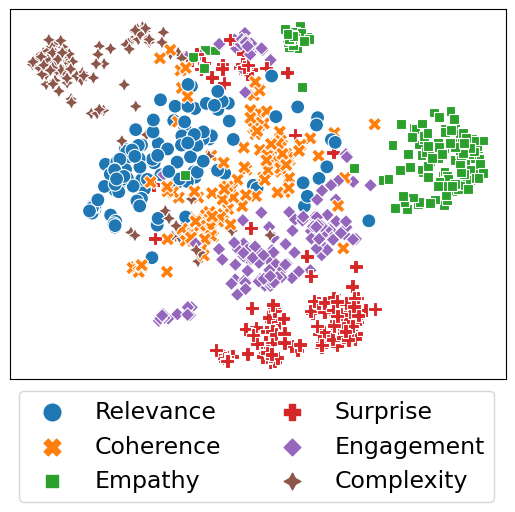

In [59]:
_ = show_embedding_visualization(embeds, df_explore, n_neighbors=300, metric='euclidean')

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, fowlkes_mallows_score

In [90]:
embeds.shape

(25310, 768)

In [ ]:
ri_array = []
adjusted_ri_array = []
adjusted_mi_array = []
fm_array = []
for i in range(10):
    print(i)
    kmeans = KMeans(n_clusters=6, n_init='auto')
    kmeans.fit(embeds)
    ri_array.append(rand_score(kmeans.labels_, flat_criteria))
    adjusted_ri_array.append(adjusted_rand_score(kmeans.labels_, flat_criteria))
    adjusted_mi_array.append(adjusted_mutual_info_score(kmeans.labels_, flat_criteria, average_method='arithmetic'))
    fm_array.append(fowlkes_mallows_score(kmeans.labels_, flat_criteria))

In [88]:
np.mean(adjusted_ri_array)

0.537198645526958

In [89]:
np.mean(adjusted_mi_array)

0.6254617291023409

In [70]:
kmeans = KMeans(n_clusters=6, n_init='auto')

In [71]:
kmeans.fit(embeds)

KMeans(n_clusters=6, n_init='auto')

In [26]:
kmeans.labels_[:10]

array([1, 1, 1, 1, 2, 2, 2, 2, 3, 3], dtype=int32)

In [27]:
flat_criteria[:10]

['Relevance',
 'Relevance',
 'Relevance',
 'Relevance',
 'Coherence',
 'Coherence',
 'Coherence',
 'Coherence',
 'Empathy',
 'Empathy']

In [72]:
rand_score(kmeans.labels_, flat_criteria)

0.8524495709884272

In [73]:
adjusted_rand_score(kmeans.labels_, flat_criteria)

0.4962330768885687

In [74]:
adjusted_mutual_info_score(kmeans.labels_, flat_criteria, average_method='arithmetic')

0.5795887221389167

In [38]:
fowlkes_mallows_score(kmeans.labels_, flat_criteria)

0.6972356773512244

In [75]:
df_explore['x'] = umap_embeds[:,0]
df_explore['y'] = umap_embeds[:,1]

alt.data_transformers.disable_max_rows()

# Plot
chart = alt.Chart(df_explore[df_explore["Model"]=="Human"]).mark_point(size=80).encode(
    x=#'x',
    alt.X('x',
        scale=alt.Scale(zero=False), axis=None
    ),
    y=
    alt.Y('y',
        scale=alt.Scale(zero=False), axis=None
    ),
    color='Criterion',
    # shape='ratings',
    # shape='Task',
    # color='Task',
    # shape='Criterion',
    shape='Criterion',
    # color='ratings',
    tooltip=['text']
).properties(
    width=700,
    height=400
).configure_legend(
    orient='bottom',
    labelFontSize=30,
    title=None,
    columns=3
)
# chart.interactive()
chart

alt.Chart(...)

### Keywords

In [ ]:
kw_extractor = yake.KeywordExtractor(n=3, dedupLim=0.3, top=30)
dico_keywords = {}
for c in CRITERIA:
    if use_chat:
        flat_explanations_c = ' '.join([answers[i][c][task_id]["choices"][0]["message"]["content"] for i in range(df.shape[0]) for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["message"]["content"]) > 10])
    else:
        flat_explanations_c = ' '.join([answers[i][c][task_id]["choices"][0]["text"] for i in range(df.shape[0]) for task_id in range(4) if len(answers[i][c][task_id]["choices"][0]["text"]) > 10])
    keywords = kw_extractor.extract_keywords(flat_explanations_c)
    dico_keywords[c] = [k[0] for k in keywords]
    print(c, '|||', ', '.join(dico_keywords[c]))

In [44]:
kw_extractor = yake.KeywordExtractor(n=3, dedupLim=0.3, top=30)
dico_keywords = {}
for c in CRITERIA:
    flat_explanations_c = ' '.join([answers[i][c]["Task {}".format(task_id)][0] for i in range(df.shape[0]) for task_id in range(4) if len(answers[i][c]["Task {}".format(task_id)][0]) > 10])
    keywords = kw_extractor.extract_keywords(flat_explanations_c)
    dico_keywords[c] = [k[0] for k in keywords]
    print(c, '|||', ', '.join(dico_keywords[c]))

Relevance ||| story, prompt, Relevance, story roughly matches, target, match, weak relationship, human, connection, weak, Mark Zuckerberg, focuses, Soviet Russia, unrelated, human story provided, address, life, Aokigahara Suicide Forest, Michael Meyers, Google, idea, difficult, President Obama, writing, Freddy Krueger, rearrangeable story, Reddit, effectively, Black Box, call
Coherence ||| story lacks coherence, story, make sense, difficult to understand, clear, target story lacks, clear narrative structure, follow, making it difficult, lacks, rate, context, coherence makes, jumps, understandable plot, setting, thoughts, dialogue, protagonist, hard, characters keep changing, explanation, logical, Additionally, time, events and characters, providing a clear, easy, mix, end
Empathy ||| empathy, story, characters' emotions, difficult to understand, understand the characters', story lacks depth, emotional connection, target story lacks, rate, making it difficult, clear, feelings, context, 

### Guidelines

In [ ]:
with open("answers_chat.json", 'r', encoding="utf-8") as myfile:
    answers = json.load(myfile)
    use_chat = True
df = ANNOTATIONS_DF
guidelines_explanations = [answers[i][c][2]["choices"][0]["message"]["content"] for i in range(df.shape[0]) for c in CRITERIA]

In [ ]:
with open("answers_explanation.json", 'r', encoding="utf-8") as myfile:
    answers = json.load(myfile)
    use_chat = False
df = ANNOTATIONS_DF
guidelines_explanations = [answers[i][c][2]["choices"][0]["text"] for i in range(df.shape[0]) for c in CRITERIA]

In [ ]:
GUIDELINES["Coherence"].split("\n")

In [ ]:
GUIDELINES_DICT = {}
for c in CRITERIA:
    GUIDELINES_DICT[c] = GUIDELINES[c].split("\n")

In [ ]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

In [ ]:
GUIDELINES_DICT[c][0]

In [ ]:
GUIDELINES_EMBED_DICT = {}
for c in CRITERIA:
    GUIDELINES_EMBED_DICT[c] = co.embed(texts=GUIDELINES_DICT[c], model='large').embeddings

In [ ]:
def return_guideline(explanation, c, full_exp=False, verbose=False):
    if full_exp:
        embedding1 = model.encode(explanation, convert_to_tensor=True)
    else:
        explanation_split = re.split('\.|\n', explanation)
        explanation_split = [x for x in explanation_split if x != '']
        try:
            explanation_part = explanation_split[1]
        except:
            print(explanation_split)
            explanation_part = explanation_split[0]
        embedding1 = model.encode(explanation_part, convert_to_tensor=True)
    g_id = np.argmax([util.pytorch_cos_sim(embedding1, model.encode(g, convert_to_tensor=True)).cpu().numpy()[0,0] for g in GUIDELINES_DICT[c]])
    if verbose:
        print(re.split('\.|\n', explanation))
        print(GUIDELINES_DICT[c][g_id])
    return g_id

In [ ]:
def return_guideline2(embedding, c, verbose=False):
    g_id = np.argmax([util.pytorch_cos_sim(embedding, g_emb) for g_emb in GUIDELINES_EMBED_DICT[c]])
    if verbose:
        print(re.split('\.|\n', explanation))
        print(GUIDELINES_DICT[c][g_id])
    return g_id

In [ ]:
return_guideline2(embeds[14], "Coherence", verbose=True)

In [ ]:
return_guideline(guidelines_explanations[1::6][3], "Coherence", verbose=True)

In [ ]:
embedding_1 = model.encode(re.split('\.|\n', guidelines_explanations[1])[1], convert_to_tensor=True)
embedding_2 = model.encode(GUIDELINES_DICT[c][i], convert_to_tensor=True)
print(util.pytorch_cos_sim(embedding_1, embedding_2).cpu().numpy()[0,0])

In [ ]:
best_explanations_full_dict = {}
best_explanations_part_dict = {}
ratings_dict = {}
for c_i, c in enumerate(CRITERIA):
    best_explanations_full = []
    best_explanations_part = []
    ratings = []
    for explanation in tqdm(guidelines_explanations[c_i::6]):
        best_explanations_full.append(return_guideline(explanation, c, full_exp=True) + 1)  # +1 for rating
        best_explanations_part.append(return_guideline(explanation, c, full_exp=False) + 1)  # +1 for rating
        ratings.append(float(re.findall(r"[-+]?(?:\d*\.*\d+)", explanation)[0]))
    best_explanations_full_dict[c] = best_explanations_full
    best_explanations_part_dict[c] = best_explanations_part
    ratings_dict[c] = ratings

In [ ]:
c_i = 1
story_id = 324
best_explanations_full_dict[CRITERIA[c_i]][story_id], best_explanations_part_dict[CRITERIA[c_i]][story_id], ratings_dict[CRITERIA[c_i]][story_id]

In [ ]:
c_i = 1
story_id = 40
print(return_guideline(guidelines_explanations[c_i::6][story_id], CRITERIA[c_i], full_exp=False, verbose=True)+1)
print(return_guideline(guidelines_explanations[c_i::6][story_id], CRITERIA[c_i], full_exp=True, verbose=True)+1)

In [ ]:
full_match_diff_dict = {}
part_match_diff_dict = {}
for c in CRITERIA:
    full_match_diff_dict[c] = np.sum(np.abs(np.asarray(best_explanations_full_dict[c]) - np.asarray(ratings_dict[c])))
    part_match_diff_dict[c] = np.sum(np.abs(np.asarray(best_explanations_part_dict[c]) - np.asarray(ratings_dict[c])))
print([full_match_diff_dict[c] for c in CRITERIA])
print([part_match_diff_dict[c] for c in CRITERIA])

In [ ]:
full_match_rate_dict = {}
part_match_rate_dict = {}
for c in CRITERIA:
    full_match_rate_dict[c] = np.sum(np.asarray(best_explanations_full_dict[c]) == np.asarray(ratings_dict[c]))
    part_match_rate_dict[c] = np.sum(np.asarray(best_explanations_part_dict[c]) == np.asarray(ratings_dict[c]))
print(np.around([full_match_rate_dict[c]/10.56 for c in CRITERIA], decimals=0))
print(np.around([part_match_rate_dict[c]/10.56 for c in CRITERIA], decimals=0))